In [28]:
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt

In [29]:
print(os.listdir(image_folder))

['2015_0.6_3239.jpg', '2015_ORG.jpg', '2005_ORG.jpg', '2005_1.2_2600.jpg', '1985_1.6_1849.6.jpg', '1991_2.0_1234.jpg', '2015_1.4_3239.jpg', '1998_1.6_428.jpg', '2020_0.6_1276.6.jpg', '2023_ORG.jpg', '1985_2.0_1849.6.jpg', '1998_ORG.jpg', '.DS_Store', '2023_0.6_2718.jpg', '1991_ORG.jpg', '2008_1.4_1427.jpg', '2020_ORG.jpg', '1991_1.2_1234.jpg', '1991_1.8_1234.jpg', '1985_0.4_1849.6.jpg', '1976_ORG.jpg', '2005_1.4_2600.jpg', '1976_1.4_3036.jpg', '1998_1.4_428.jpg', '2015_1.2_3239.jpg', '1998_2.0_428.jpg', '2020_1.4_1276.6.jpg', '2005_0.6_2600.jpg', '1991_0.4_1234.jpg', '2023_1.6_2718.jpg', '2008_0.8_1427.jpg', '1991_1.6_1234.jpg', '1998_1.8_428.jpg', '2020_1.2_1276.6.jpg', '1976_0.2_3036.jpg', '1996_ORG.jpg', '1985_0.2_1849.6.jpg', '1996_1.2_1416.jpg', '2005_0.8_2600.jpg', '.ipynb_checkpoints', '2015_0.8_3239.jpg', '2020_1.8_1276.6.jpg', '1996_0.6_1416.jpg', '2005_0.4_2600.jpg', '2015_0.2_3239.jpg', '1985_0.8_1849.6.jpg', '2005_1.6_2600.jpg', '2008_ORG.jpg', '1996_2.0_1416.jpg', '2023_0.

In [30]:
def create_flood_mask(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Adjust if needed based on your images
    lower = np.array([90, 50, 50])
    upper = np.array([140, 255, 255])

    mask = cv2.inRange(hsv, lower, upper)
    return mask

image_folder = "flood_dataset"
mask_folder = "masks"

os.makedirs(mask_folder, exist_ok=True)

files = [f for f in os.listdir(image_folder) 
         if f.lower().endswith((".jpg", ".png"))]

for file in files:
    if "ORG" in file:
        continue

    img_path = os.path.join(image_folder, file)
    mask_path = os.path.join(mask_folder, file)

    img = cv2.imread(img_path)

    mask = create_flood_mask(img)
    cv2.imwrite(mask_path, mask)

print("✅ Flood masks created!")


✅ Flood masks created!


In [31]:
IMAGE_SIZE = 128

def load_data(image_folder, mask_folder):
    images = []
    masks = []

    files = [f for f in os.listdir(image_folder) 
             if f.lower().endswith((".png", ".jpg", ".jpeg"))]

    print("Total files found:", len(files))

    for file in files:
        try:
            if "ORG" in file:
                continue

            parts = file.replace(".jpg", "").replace(".png", "").split("_")
            multiplier = float(parts[1])

            # ✅ normalize multiplier (VERY IMPORTANT)
            multiplier = multiplier / 2.0

            img_path = os.path.join(image_folder, file)
            mask_path = os.path.join(mask_folder, file)

            if not os.path.exists(mask_path):
                continue

            # Load image
            img = cv2.imread(img_path)
            img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
            img = img / 255.0

            multiplier_channel = np.ones((IMAGE_SIZE, IMAGE_SIZE, 1)) * multiplier
            img = np.concatenate([img, multiplier_channel], axis=-1)

            # Load mask
            mask = cv2.imread(mask_path, 0)
            mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE))

            # ✅ convert to binary
            mask = (mask > 0).astype(np.float32)
            mask = np.expand_dims(mask, axis=-1)

            images.append(img)
            masks.append(mask)

        except Exception as e:
            print("Error:", file, e)

    return np.array(images), np.array(masks)

X, y = load_data(image_folder, mask_folder)
print("Shape:", X.shape, y.shape)


Total files found: 52
Shape: (42, 128, 128, 4) (42, 128, 128, 1)


In [32]:
def unet_model(input_shape=(128, 128, 4)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(c3)
    c3 = layers.Dropout(0.3)(c3)
    p3 = layers.MaxPooling2D()(c3)

    # Bottleneck
    b = layers.Conv2D(256, 3, activation='relu', padding='same')(p3)
    b = layers.Conv2D(256, 3, activation='relu', padding='same')(b)
    b = layers.Dropout(0.3)(b)

    # Decoder
    u1 = layers.UpSampling2D()(b)
    u1 = layers.concatenate([u1, c3])
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.concatenate([u2, c2])
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(u2)

    u3 = layers.UpSampling2D()(c5)
    u3 = layers.concatenate([u3, c1])
    c6 = layers.Conv2D(32, 3, activation='relu', padding='same')(u3)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c6)

    return Model(inputs, outputs)

In [34]:
def dice_loss(y_true, y_pred):
    smooth = 1e-6
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    return 1 - (2. * intersection + smooth) / \
           (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

In [35]:
model = unet_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=['accuracy']
)

history = model.fit(
    X, y,
    batch_size=4,
    epochs=50,
    validation_split=0.2
)

# Save model (recommended format)
model.save("flood_unet_model.keras")


Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 200ms/step - accuracy: 0.8553 - loss: 1.4146 - val_accuracy: 0.9364 - val_loss: 1.2149
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 193ms/step - accuracy: 0.9349 - loss: 1.2128 - val_accuracy: 0.9364 - val_loss: 1.2033
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 205ms/step - accuracy: 0.9349 - loss: 1.1659 - val_accuracy: 0.9364 - val_loss: 1.1401
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 229ms/step - accuracy: 0.9349 - loss: 1.1029 - val_accuracy: 0.9364 - val_loss: 1.0511
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 198ms/step - accuracy: 0.9349 - loss: 0.9749 - val_accuracy: 0.9364 - val_loss: 0.8796
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step - accuracy: 0.9373 - loss: 0.8033 - val_accuracy: 0.9487 - val_loss: 0.7353
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step - accuracy: 0.9448 - loss: 0.7251 - val_accuracy: 0.9274 - val_loss: 0.7182
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 183ms/step - accuracy: 0.9350 - loss: 0.6591 - val_accuracy: 0.9406 - val_loss:

In [36]:
def predict_with_multiplier(model, image_path, multiplier):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (128, 128))
    img = img / 255.0

    # normalize multiplier
    multiplier = multiplier / 2.0

    multiplier_channel = np.ones((128,128,1)) * multiplier
    input_img = np.concatenate([img, multiplier_channel], axis=-1)

    input_img = np.expand_dims(input_img, axis=0)

    pred = model.predict(input_img)[0]
    pred = (pred > 0.5).astype(np.uint8)

    return img, pred


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


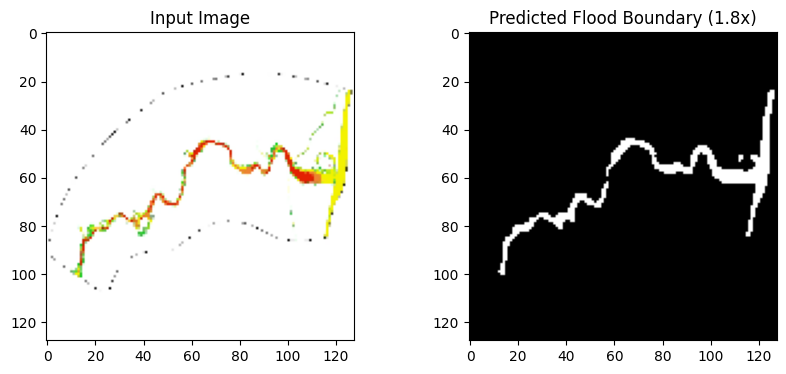

In [37]:
test_image = "flood_dataset/1976_0.2_3036.jpg"

img, pred = predict_with_multiplier(model, test_image, multiplier=1.8)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Input Image")

plt.subplot(1,2,2)
plt.imshow(pred.squeeze(), cmap='gray')
plt.title("Predicted Flood Boundary (1.8x)")

plt.show()

In [38]:
def compute_flooded_area(mask):
    # mask is binary (0 or 1)
    return np.sum(mask)

In [39]:
peaks = []
areas = []

files = [f for f in os.listdir(image_folder) 
         if f.lower().endswith((".jpg", ".png"))]

for file in files:
    if "ORG" in file:
        continue

    try:
        # Extract peak from filename
        parts = file.replace(".jpg", "").replace(".png", "").split("_")
        multiplier = float(parts[1])
        peak = float(parts[2])

        # Final peak after multiplier
        scaled_peak = peak * multiplier

        mask_path = os.path.join(mask_folder, file)

        if not os.path.exists(mask_path):
            continue

        mask = cv2.imread(mask_path, 0)
        mask = cv2.resize(mask, (128,128))
        mask = (mask > 0).astype(np.float32)

        area = compute_flooded_area(mask)

        peaks.append(scaled_peak)
        areas.append(area)

    except:
        continue

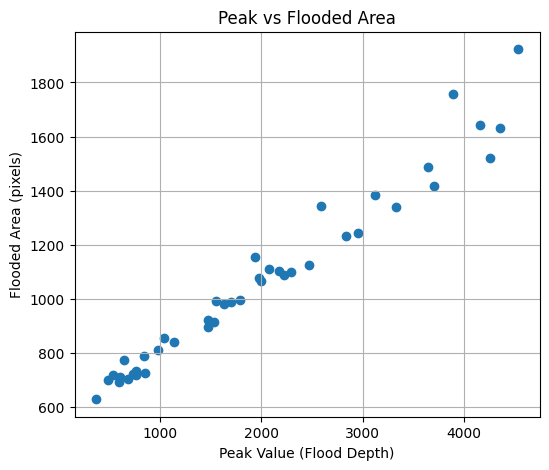

In [40]:
plt.figure(figsize=(6,5))

plt.scatter(peaks, areas)
plt.xlabel("Peak Value (Flood Depth)")
plt.ylabel("Flooded Area (pixels)")
plt.title("Peak vs Flooded Area")

plt.grid()
plt.show()